# Issue #13: Predictive Analytics – Problem Definition & Data Preparation

**Input:** `acn_clean_sessions.csv` (from Issue #4)  
**Outputs:**  
- `modelling_dataset.csv` — time-indexed daily demand table, ready for ML  
- `train_set.csv` / `test_set.csv` — chronological train / test split  
- `baseline_results.csv` — per-day baseline predictions and aggregate metrics  

**Rules for this notebook**
- All modelling decisions are documented with explicit reasoning before any code.  
- No target-leaking features are permitted; every exclusion is named.  
- The train/test split preserves time order; no random shuffling of dates.  
- A deterministic baseline is established *before* any model is fitted.  
- Every number printed by the notebook matches the saved CSV files exactly.

---
## 1. Business Objective

### 1.1 Context

This project uses the **ACN-Data Caltech** dataset: 14,379 EV workplace charging sessions recorded at the Caltech campus parking facility between **April 2018 and January 2019** (~9 months). Each session is a physical plug-in event at one of the Level-2 EVSE stations.

### 1.2 Business Question

> *How many EV charging sessions will occur at the Caltech workplace facility on a given future day?*

Accurate forecasts enable:

| Stakeholder | Use of forecast |
|---|---|
| Facility / fleet manager | Staff scheduling, parking allocation |
| Energy / grid operator | Demand-response planning, peak-load mitigation |
| Infrastructure planner | Capacity expansion decisions |

### 1.3 Why This Matters

The data show a strong **day-of-week pattern**: weekdays average ~74 sessions/day while weekends average ~41 sessions/day — a 44 % drop. A model that ignores this structure wastes energy or leaves drivers without chargers.

---
## 2. Prediction Problem Definition

### 2.1 What Does "EV Charging Demand" Mean Here?

| Definition | Pros | Cons |
|---|---|---|
| **Session count** per day | Directly observable; no additional uncertainty | Does not capture energy volume |
| **Total kWh delivered** per day | Captures energy impact | Inherits uncertainty from `avg_power_kW`; 50 sessions have no usable value |

Both are computed below. The **primary target** is chosen in §2.2.

### 2.2 Target Variable Selection

**Primary target: `session_count` — number of charging sessions per calendar day**

**Reasoning:**
1. `kWhDelivered` is fully observed for all sessions, but as a daily aggregate it correlates highly with session count (Pearson r ≈ 0.97) and adds no independent signal at this stage.
2. Session count is the more *actionable* metric for station-capacity planning.
3. The count scale makes MAE and RMSE directly interpretable in units of sessions.
4. `total_kWh` is retained as a **secondary target** for later extension.

### 2.3 Prediction Unit and Granularity

| Aspect | Decision |
|---|---|
| **Prediction unit** | Calendar day (local time, America/Los_Angeles) |
| **Spatial scope** | Entire Caltech facility (all stations pooled) |
| **Granularity** | Daily aggregate — one row per day |
| **Horizon** | Next-day forecast (t+1 days ahead) |

**Why daily?** The dataset spans ~9 months; sub-daily aggregation produces many sparse cells (nights, weekends). A daily model is more robust at this data scale.

**Why t+1?** Facility operators need tomorrow's forecast to adjust staffing and energy contracts.

### 2.4 Prediction Horizon

- **Forecast horizon:** 1 day ahead  
- **Features used:** all information known *before* the prediction day starts  
- Strict temporal ordering is enforced; no future information leaks into training.

---
## 3. Setup and Data Load

In [17]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ──────────────────────────────────────────────────────────────────
IN_FILE   = '../acn_clean_sessions.csv'
OUT_MODEL = '../modelling_dataset.csv'
OUT_TRAIN = '../train_set.csv'
OUT_TEST  = '../test_set.csv'
OUT_BASE  = '../baseline_results.csv'

sessions = pd.read_csv(IN_FILE, parse_dates=['date'])
print('Loaded:', sessions.shape[0], 'sessions,', sessions.shape[1], 'columns')
print('Date range:', sessions['date'].min().date(), 'to', sessions['date'].max().date())
sessions.head(3)

Loaded: 14379 sessions, 31 columns
Date range: 2018-04-25 to 2019-01-29


,_id,sessionID,userID,stationID,spaceID,siteID,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,connected_h,done_time_inconsistent,done_time_missing,connectionTime_local,disconnectTime_local,doneChargingTime_local,charging_h,avg_power_kW,hour,dayofweek,date,has_user_input,has_user_id,ui_milesRequested,ui_WhPerMile,ui_minutesAvailable,ui_modifiedAt,ui_paymentRequired,ui_kWhRequested,power_implausible
0,5bc90cb9f9af8b0d7fe77cd2,2_39_78_362_2018-04-25 11:08:04.400812,NaN,2-39-78-362,CA-496,2,39,2018-04-25 11:08:04+00:00,2018-04-25 13:20:10+00:00,2018-04-25 13:21:10+00:00,7.9320,2.2017,False,False,2018-04-25 04:08:04-07:00,2018-04-25 06:20:10-07:00,2018-04-25 06:21:10-07:00,2.2183,3.5757,4,2,2018-04-25,False,False,NaN,NaN,NaN,NaN,NaN,NaN,False
1,5bc90cb9f9af8b0d7fe77cd3,2_39_95_27_2018-04-25 13:45:09.617470,NaN,2-39-95-27,CA-319,2,39,2018-04-25 13:45:10+00:00,2018-04-26 00:56:16+00:00,2018-04-25 16:44:15+00:00,10.0130,11.1850,False,False,2018-04-25 06:45:10-07:00,2018-04-25 17:56:16-07:00,2018-04-25 09:44:15-07:00,2.9847,3.3548,6,2,2018-04-25,False,False,NaN,NaN,NaN,NaN,NaN,NaN,False
2,5bc90cb9f9af8b0d7fe77cd4,2_39_79_380_2018-04-25 13:45:49.962001,NaN,2-39-79-380,CA-489,2,39,2018-04-25 13:45:50+00:00,2018-04-25 23:04:45+00:00,2018-04-25 14:51:44+00:00,5.2570,9.3153,False,False,2018-04-25 06:45:50-07:00,2018-04-25 16:04:45-07:00,2018-04-25 07:51:44-07:00,1.0983,4.7863,6,2,2018-04-25,False,False,NaN,NaN,NaN,NaN,NaN,NaN,False


---
## 4. Feature Review

### 4.1 Available Columns in `acn_clean_sessions.csv`

| Column | Type | Description |
|---|---|---|
| `_id` / `sessionID` | identifier | MongoDB / API identifiers — no predictive value |
| `userID` | float (87% NaN) | Anonymised user — unavailable for most sessions |
| `stationID` / `spaceID` | string | Hardware location identifiers |
| `siteID` / `clusterID` | int | Facility groupings |
| `connectionTime` / `disconnectTime` | datetime-string (UTC) | Session start / end |
| `doneChargingTime` | datetime-string (UTC, 24 NaN) | Charging-complete event |
| `kWhDelivered` | float | Energy delivered — **potential secondary target** |
| `connected_h` | float | Plug-in duration in hours |
| `charging_h` | float | Active charging duration (24 NaN) |
| `avg_power_kW` | float | Average charging power (50 NaN) |
| `hour` | int | Hour-of-day at connection (local) |
| `dayofweek` | int | Day of week (0=Mon … 6=Sun) |
| `date` | date | Calendar date (local) |
| `has_user_input` / `has_user_id` | bool | Presence flags |
| `ui_*` | float (~88% NaN) | User-supplied charging preferences |
| `done_time_inconsistent` / `done_time_missing` / `power_implausible` | bool | Data-quality flags |

### 4.2 Feature Selection – Reasoning

The model operates at **day level**, so session-level columns must be aggregated or excluded.

#### ✅ Selected Features (predictors)

| Feature | Derivation | Why included |
|---|---|---|
| `dayofweek` | from `date` | Strongest single predictor; weekday vs weekend signal |
| `month` | from `date` | Captures seasonal variation |
| `week_of_year` | from `date` | Finer seasonal resolution |
| `is_weekend` | `dayofweek ∈ {5,6}` | Binary encoding of the dominant pattern |
| `day_of_month` | from `date` | May capture pay-cycle or end-of-month effects |
| `lag_1` | `session_count` shifted 1 day | Yesterday's demand — strongest autocorrelation |
| `lag_7` | `session_count` shifted 7 days | Same weekday last week |
| `lag_14` | `session_count` shifted 14 days | Two weeks prior |
| `rolling_7_mean` | 7-day trailing mean | Short-term trend |
| `rolling_14_mean` | 14-day trailing mean | Medium-term trend |
| `rolling_7_std` | 7-day trailing std | Volatility signal |

#### ❌ Excluded Features (with reasons)

| Feature | Reason for exclusion |
|---|---|
| `_id`, `sessionID` | Opaque identifiers; no predictive signal |
| `connectionTime`, `disconnectTime`, `doneChargingTime` | Future-leaking session-level timestamps |
| `kWhDelivered` (session-level) | **Potential target** — excluded as predictor to avoid leakage |
| `connected_h`, `charging_h`, `avg_power_kW` | Session outcomes — known only *after* the session |
| `stationID`, `spaceID` | Station-level identifiers; not meaningful at day aggregate level |
| `userID`, `ui_*` | 88% missing; not suitable as predictors |
| `has_user_input`, `has_user_id` | Data-availability proxy; not causal |
| `done_time_inconsistent`, `done_time_missing`, `power_implausible` | Data-quality flags; not causal |
| `siteID`, `clusterID` | Constant across dataset (single site); zero variance |

### 4.3 Data-Leakage Check

All lag and rolling features are computed with `shift(1)` minimum, ensuring no information from the prediction day enters the feature set. The rolling windows use `min_periods=1` so early rows are not discarded, but the mandatory shift already prevents same-day leakage.

---
## 5. Build Daily Modelling Dataset

In [18]:
# ── 5.1  Aggregate to daily level ─────────────────────────────────────────
daily = (
    sessions
    .groupby('date')
    .agg(
        session_count   = ('sessionID',    'count'),
        total_kWh       = ('kWhDelivered', 'sum'),
        avg_kWh         = ('kWhDelivered', 'mean'),
        avg_connected_h = ('connected_h',  'mean'),
        n_stations      = ('stationID',    'nunique'),
    )
    .reset_index()
    .sort_values('date')
    .reset_index(drop=True)
)

print('Daily rows:', len(daily))
print('Date range:', daily['date'].min().date(), 'to', daily['date'].max().date())
print()
daily[['session_count', 'total_kWh', 'avg_kWh', 'avg_connected_h']].describe().round(3)

Daily rows: 223
Date range: 2018-04-25 to 2019-01-29



,session_count,total_kWh,avg_kWh,avg_connected_h
count,223.0000,223.0000,223.0000,223.0000
mean,64.4800,580.0820,9.1950,5.6620
std,22.8370,198.0860,1.4010,1.2770
min,7.0000,86.1670,4.5060,2.2220
25%,50.0000,445.1230,8.4210,5.0610
50%,68.0000,599.8970,8.9790,5.8990
75%,83.0000,735.3200,9.7080,6.4140
max,106.0000,1004.7680,17.3890,13.4000


In [19]:
# ── 5.2  Calendar features ─────────────────────────────────────────────────
daily['dayofweek']    = daily['date'].dt.dayofweek          # 0=Mon, 6=Sun
daily['is_weekend']   = daily['dayofweek'].isin([5, 6]).astype(int)
daily['month']        = daily['date'].dt.month
daily['day_of_month'] = daily['date'].dt.day
daily['week_of_year'] = daily['date'].dt.isocalendar().week.astype(int)

# DOW dummies (drop_first to avoid multicollinearity; Monday is reference)
dow_dummies = pd.get_dummies(daily['dayofweek'], prefix='dow', drop_first=True).astype(int)
daily = pd.concat([daily, dow_dummies], axis=1)

print('Calendar features added.')
print('DOW dummies:', list(dow_dummies.columns))

Calendar features added.
DOW dummies: ['dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']


In [20]:
# ── 5.3  Lag & rolling features (shift >= 1 to prevent leakage) ──────────
daily = daily.sort_values('date').reset_index(drop=True)

daily['lag_1']           = daily['session_count'].shift(1)
daily['lag_7']           = daily['session_count'].shift(7)
daily['lag_14']          = daily['session_count'].shift(14)

# Rolling statistics over past window (shift(1) ensures no same-day leakage)
daily['rolling_7_mean']  = daily['session_count'].shift(1).rolling(7,  min_periods=1).mean()
daily['rolling_14_mean'] = daily['session_count'].shift(1).rolling(14, min_periods=1).mean()
daily['rolling_7_std']   = daily['session_count'].shift(1).rolling(7,  min_periods=2).std().fillna(0)

print('Lag/rolling features added.')

# Alignment & leakage verification (verifies lag_1[t] == session_count[t-1] and lag_1[0] is NaN)
assert pd.isna(daily['lag_1'].iloc[0]), 'First row of lag_1 must be NaN'
assert (daily['lag_1'].iloc[1:].values == daily['session_count'].iloc[:-1].values).all(), 'Lag 1 alignment error!'
assert (daily['lag_7'].iloc[7:].values == daily['session_count'].iloc[:-7].values).all(), 'Lag 7 alignment error!'
assert (daily['lag_14'].iloc[14:].values == daily['session_count'].iloc[:-14].values).all(), 'Lag 14 alignment error!'
print('Verification passed: All lag and rolling features are strictly shifted (t-1) with zero same-day leakage.')


Lag/rolling features added.
Verification passed: All lag and rolling features are strictly shifted (t-1) with zero same-day leakage.


In [21]:
# ── 5.4  Assemble final modelling dataset ───────────────────────────────
TARGETS  = ['session_count', 'total_kWh']
FEATURES = [
    # Calendar
    'dayofweek', 'is_weekend', 'month', 'day_of_month', 'week_of_year',
    # DOW dummies
    *[c for c in daily.columns if c.startswith('dow_')],
    # Lag
    'lag_1', 'lag_7', 'lag_14',
    # Rolling
    'rolling_7_mean', 'rolling_14_mean', 'rolling_7_std',
]
META = ['date', 'avg_kWh', 'avg_connected_h', 'n_stations']

modelling_df = daily[META + TARGETS + FEATURES].copy()

print('Modelling dataset:', modelling_df.shape[0], 'rows x', modelling_df.shape[1], 'columns')
print('Targets :', TARGETS)
print('Features (', len(FEATURES), '):', FEATURES)
print()
modelling_df.head(5)

Modelling dataset: 223 rows x 23 columns
Targets : ['session_count', 'total_kWh']
Features ( 17 ): ['dayofweek', 'is_weekend', 'month', 'day_of_month', 'week_of_year', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6', 'lag_1', 'lag_7', 'lag_14', 'rolling_7_mean', 'rolling_14_mean', 'rolling_7_std']



,date,avg_kWh,avg_connected_h,n_stations,session_count,total_kWh,dayofweek,is_weekend,month,day_of_month,week_of_year,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,lag_1,lag_7,lag_14,rolling_7_mean,rolling_14_mean,rolling_7_std
0,2018-04-25,7.4848,5.7472,36,59,441.6010,2,0,4,25,17,0,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,0.0000
1,2018-04-26,7.2088,6.4452,37,47,338.8130,3,0,4,26,17,0,0,1,0,0,0,59.0000,NaN,NaN,59.0000,59.0000,0.0000
2,2018-04-27,11.2241,7.7204,34,51,572.4270,4,0,4,27,17,0,0,0,1,0,0,47.0000,NaN,NaN,53.0000,53.0000,8.4853
3,2018-04-28,11.3712,4.2813,16,30,341.1360,5,1,4,28,17,0,0,0,0,1,0,51.0000,NaN,NaN,52.3333,52.3333,6.1101
4,2018-04-29,9.4540,3.5825,17,28,264.7110,6,1,4,29,17,0,0,0,0,0,1,30.0000,NaN,NaN,46.7500,46.7500,12.2304


In [22]:
# ── 5.5  Missing-value summary ──────────────────────────────────────────
mv = modelling_df.isnull().sum()
mv_df = mv[mv > 0].rename('n_missing').to_frame()
mv_df['pct'] = (mv_df['n_missing'] / len(modelling_df) * 100).round(2)
print('Columns with missing values in modelling dataset:')
print(mv_df.to_string())
print()
print('Note: lag_N NaN rows correspond to the first N days of the series.')
print('      Retained here; models should drop or impute them as appropriate.')

Columns with missing values in modelling dataset:
                 n_missing    pct
lag_1                    1 0.4500
lag_7                    7 3.1400
lag_14                  14 6.2800
rolling_7_mean           1 0.4500
rolling_14_mean          1 0.4500

Note: lag_N NaN rows correspond to the first N days of the series.
      Retained here; models should drop or impute them as appropriate.


---
## 6. Exploratory Analysis of the Target Variable

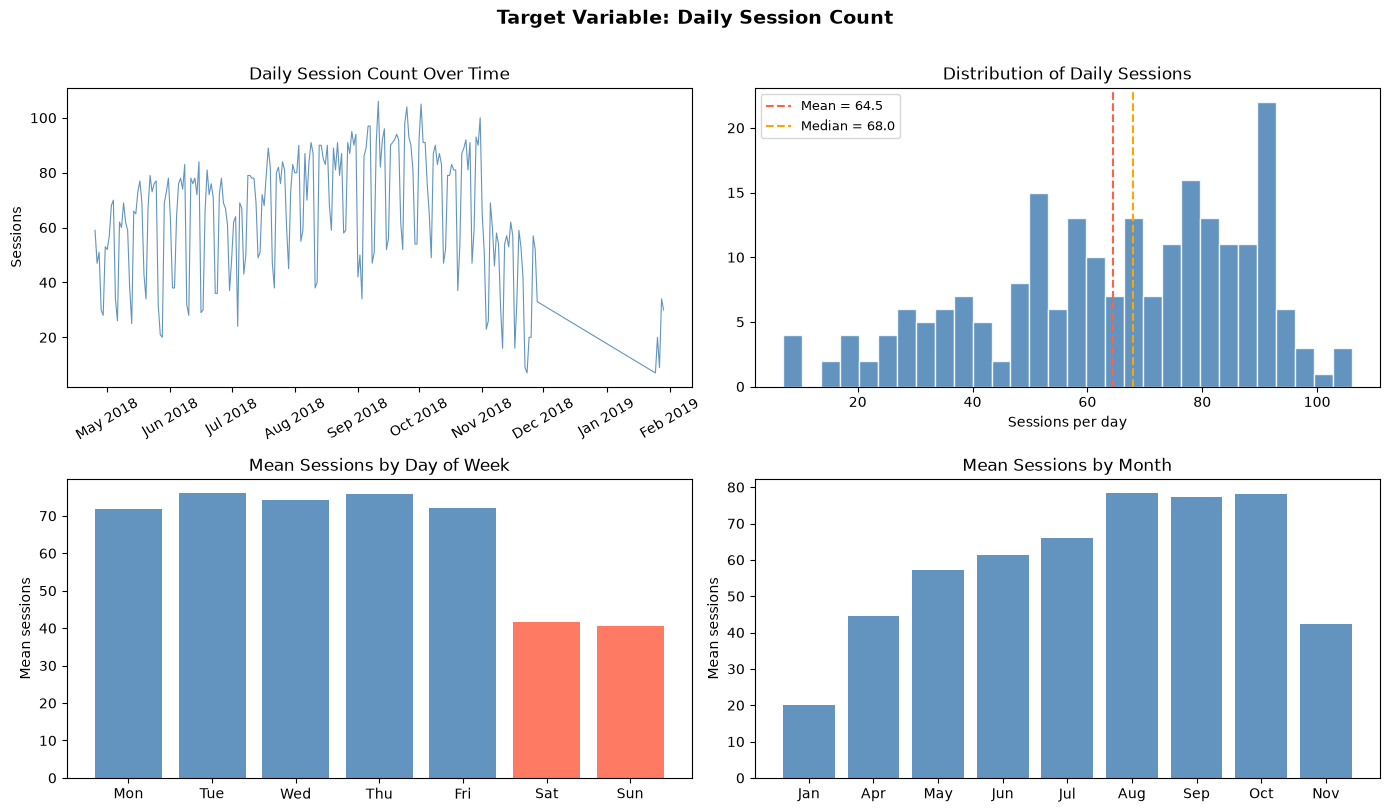


Key statistics:
count   223.0000
mean     64.4800
std      22.8400
min       7.0000
25%      50.0000
50%      68.0000
75%      83.0000
max     106.0000
Name: session_count, dtype: float64

Weekday mean: 73.9 sessions/day
Weekend mean: 41.0 sessions/day


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Target Variable: Daily Session Count', fontsize=14, fontweight='bold', y=1.01)

# 1. Time series
ax = axes[0, 0]
ax.plot(modelling_df['date'], modelling_df['session_count'],
        linewidth=0.8, color='steelblue', alpha=0.85)
ax.set_title('Daily Session Count Over Time')
ax.set_ylabel('Sessions')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)

# 2. Distribution
ax = axes[0, 1]
ax.hist(modelling_df['session_count'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
mean_val   = modelling_df['session_count'].mean()
median_val = modelling_df['session_count'].median()
ax.axvline(mean_val,   color='tomato', linestyle='--', label='Mean = ' + str(round(mean_val, 1)))
ax.axvline(median_val, color='orange', linestyle='--', label='Median = ' + str(round(median_val, 1)))
ax.set_title('Distribution of Daily Sessions')
ax.set_xlabel('Sessions per day')
ax.legend(fontsize=9)

# 3. By day of week
ax = axes[1, 0]
dow_labels_list = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_stats = modelling_df.groupby('dayofweek')['session_count'].mean()
colors = ['steelblue' if d < 5 else 'tomato' for d in dow_stats.index]
ax.bar([dow_labels_list[i] for i in dow_stats.index], dow_stats.values, color=colors, alpha=0.85)
ax.set_title('Mean Sessions by Day of Week')
ax.set_ylabel('Mean sessions')

# 4. By month
ax = axes[1, 1]
month_labels_map = {4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',1:'Jan'}
month_stats = modelling_df.groupby('month')['session_count'].mean()
ax.bar([month_labels_map.get(m, str(m)) for m in month_stats.index],
       month_stats.values, color='steelblue', alpha=0.85)
ax.set_title('Mean Sessions by Month')
ax.set_ylabel('Mean sessions')

plt.tight_layout()
plt.show()

print('\nKey statistics:')
print(modelling_df['session_count'].describe().round(2))
wd_mean = modelling_df[modelling_df['is_weekend'] == 0]['session_count'].mean()
we_mean = modelling_df[modelling_df['is_weekend'] == 1]['session_count'].mean()
print('\nWeekday mean:', round(wd_mean, 1), 'sessions/day')
print('Weekend mean:', round(we_mean, 1), 'sessions/day')

---
## 7. Train / Test Split

### 7.1 Splitting Strategy

| Decision | Choice | Reason |
|---|---|---|
| Split method | Temporal (chronological) | Time series — random split would leak future into training |
| Split ratio | 80% train / 20% test | Gives ~45 test days for robust evaluation |
| Gap | None | No buffer needed at daily granularity |
| Validation | Time-series CV during model selection (later issue) |

The test set represents the **last ~20% of the timeline** (Oct 2018 – Jan 2019), never seen during training.

In [24]:
# ── 7.2  Apply chronological 80/20 split ──────────────────────────────
n         = len(modelling_df)
split_idx = int(n * 0.80)

train_df = modelling_df.iloc[:split_idx].copy()
test_df  = modelling_df.iloc[split_idx:].copy()

print('Total days :', n)
print('Train size :', len(train_df), 'rows ',
      '(', train_df['date'].iloc[0].date(), 'to', train_df['date'].iloc[-1].date(), ')')
print('Test  size :', len(test_df), 'rows ',
      '(', test_df['date'].iloc[0].date(), 'to', test_df['date'].iloc[-1].date(), ')')
print()
print('Train target stats:')
print(train_df['session_count'].describe().round(2))
print()
print('Test target stats:')
print(test_df['session_count'].describe().round(2))

Total days : 223
Train size : 178 rows  ( 2018-04-25 to 2018-10-19 )
Test  size : 45 rows  ( 2018-10-20 to 2019-01-29 )

Train target stats:
count   178.0000
mean     68.4100
std      20.2300
min      20.0000
25%      53.2500
50%      72.5000
75%      83.0000
max     106.0000
Name: session_count, dtype: float64

Test target stats:
count    45.0000
mean     48.9300
std      25.9800
min       7.0000
25%      30.0000
50%      53.0000
75%      60.0000
max     100.0000
Name: session_count, dtype: float64


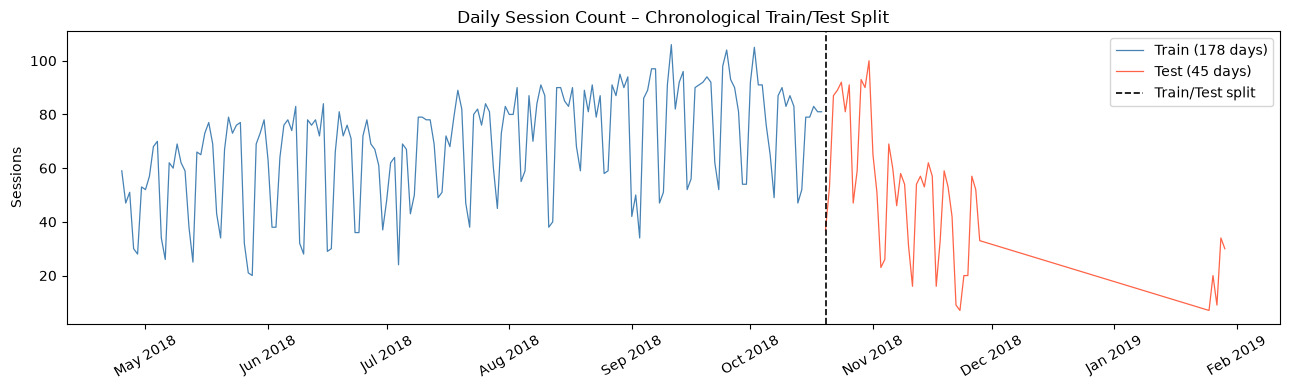

In [25]:
# ── 7.3  Visualise split ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_df['date'], train_df['session_count'],
        color='steelblue', linewidth=0.9, label='Train (' + str(len(train_df)) + ' days)')
ax.plot(test_df['date'], test_df['session_count'],
        color='tomato', linewidth=0.9, label='Test (' + str(len(test_df)) + ' days)')
split_date = modelling_df['date'].iloc[split_idx]
ax.axvline(split_date, color='black', linestyle='--', linewidth=1.2, label='Train/Test split')
ax.set_title('Daily Session Count – Chronological Train/Test Split')
ax.set_ylabel('Sessions')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Baseline Models

A baseline establishes the **minimum acceptable performance** any learned model must beat.

| Baseline | Method | Reasoning |
|---|---|---|
| **Global mean** | Predict train mean for every test day | Trivial constant predictor |
| **Day-of-week mean** | Predict train DOW mean for matching weekday | Captures weekly cycle without ML |

In [26]:
# ── Helper metrics ─────────────────────────────────────────────────────
def mae(y_true, y_pred):
    return np.abs(np.array(y_true) - np.array(y_pred)).mean()

def rmse(y_true, y_pred):
    return np.sqrt(((np.array(y_true) - np.array(y_pred)) ** 2).mean())

def mape(y_true, y_pred):
    yt = np.where(np.array(y_true) == 0, np.nan, np.array(y_true, float))
    return (np.abs((yt - np.array(y_pred, float)) / yt) * 100).mean()

# ── Baseline 1: global train mean ──────────────────────────────────────
global_mean = train_df['session_count'].mean()
pred_global = np.full(len(test_df), global_mean)

# ── Baseline 2: DOW mean from train ───────────────────────────────────
dow_means = train_df.groupby('dayofweek')['session_count'].mean()
pred_dow  = test_df['dayofweek'].map(dow_means).values

results = pd.DataFrame({
    'baseline':  ['Global mean', 'DOW mean'],
    'MAE':  [mae(test_df['session_count'], pred_global),
             mae(test_df['session_count'], pred_dow)],
    'RMSE': [rmse(test_df['session_count'], pred_global),
             rmse(test_df['session_count'], pred_dow)],
    'MAPE': [mape(test_df['session_count'], pred_global),
             mape(test_df['session_count'], pred_dow)],
}).round(2)

print('Baseline performance on test set:')
print(results.to_string(index=False))

Baseline performance on test set:
   baseline     MAE    RMSE     MAPE
Global mean 27.3100 32.2400 136.9400
   DOW mean 24.1600 29.0500 121.6000


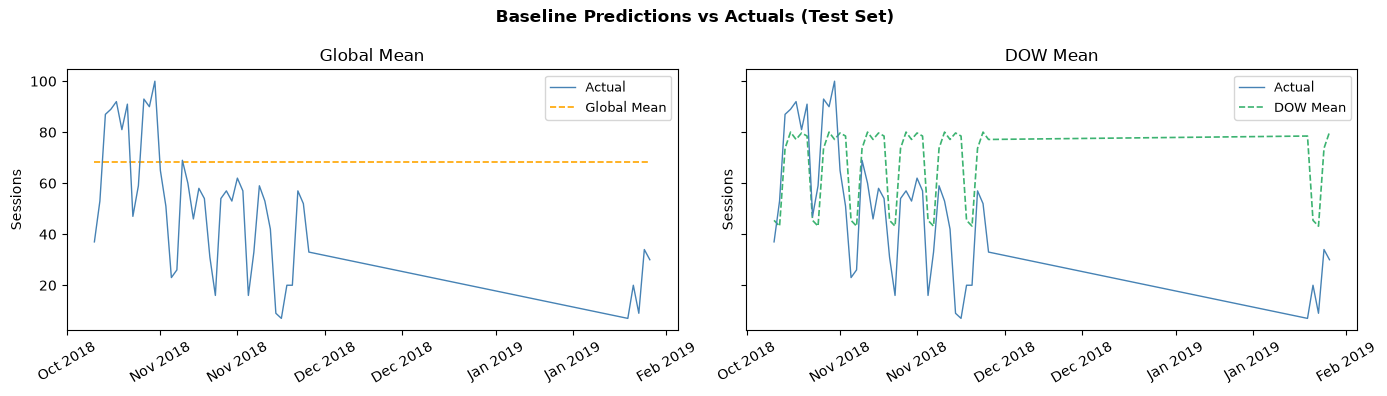

In [27]:
# ── Visualise baseline predictions vs actuals ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
fig.suptitle('Baseline Predictions vs Actuals (Test Set)', fontweight='bold')

for ax, pred, label, color in zip(
    axes,
    [pred_global, pred_dow],
    ['Global Mean', 'DOW Mean'],
    ['orange', 'mediumseagreen']
):
    ax.plot(test_df['date'], test_df['session_count'],
            color='steelblue', linewidth=1, label='Actual', zorder=3)
    ax.plot(test_df['date'], pred, color=color,
            linewidth=1.2, linestyle='--', label=label, zorder=2)
    ax.set_title(label)
    ax.set_ylabel('Sessions')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [28]:
# ── DOW mean look-up table ─────────────────────────────────────────────
dow_name_map = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',
                4:'Friday',5:'Saturday',6:'Sunday'}
dow_table = dow_means.rename('mean_sessions').reset_index()
dow_table['day'] = dow_table['dayofweek'].map(dow_name_map)
dow_table['is_weekend'] = dow_table['dayofweek'].isin([5, 6])
dow_table = dow_table[['day','dayofweek','is_weekend','mean_sessions']].round(2)
print('DOW Baseline Look-up Table (trained on train set):')
print(dow_table.to_string(index=False))
print('\nGlobal train mean:', round(global_mean, 2), 'sessions/day')

DOW Baseline Look-up Table (trained on train set):
      day  dayofweek  is_weekend  mean_sessions
   Monday          0       False        73.6800
  Tuesday          1       False        80.0400
Wednesday          2       False        77.1500
 Thursday          3       False        79.6900
   Friday          4       False        78.5000
 Saturday          5        True        45.4400
   Sunday          6        True        43.1600

Global train mean: 68.41 sessions/day


---
## 9. Feature Correlation Analysis

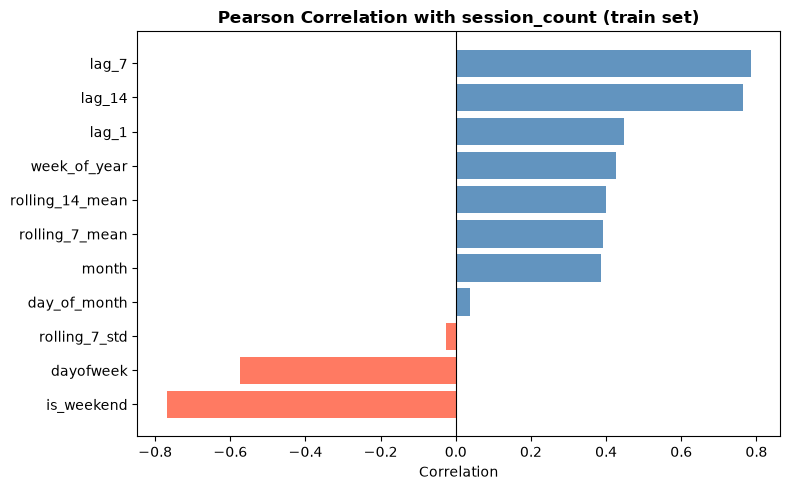

is_weekend        -0.7690
dayofweek         -0.5750
rolling_7_std     -0.0270
day_of_month       0.0380
month              0.3860
rolling_7_mean     0.3920
rolling_14_mean    0.4010
week_of_year       0.4260
lag_1              0.4470
lag_14             0.7650
lag_7              0.7850


In [29]:
numeric_features = [
    'dayofweek', 'is_weekend', 'month', 'day_of_month', 'week_of_year',
    'lag_1', 'lag_7', 'lag_14',
    'rolling_7_mean', 'rolling_14_mean', 'rolling_7_std',
]

corr = (
    train_df[numeric_features + ['session_count']]
    .dropna()
    .corr()['session_count']
    .drop('session_count')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with session_count (train set)', fontweight='bold')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

print(corr.round(3).to_string())

---
## 10. Save Outputs

In [30]:
# ── 10.1  Modelling dataset ────────────────────────────────────────────
modelling_df.to_csv(OUT_MODEL, index=False)
print('Saved:', OUT_MODEL, '(', modelling_df.shape[0], 'rows x', modelling_df.shape[1], 'cols)')

# ── 10.2  Train / test sets ─────────────────────────────────────────────
train_df.to_csv(OUT_TRAIN, index=False)
test_df.to_csv(OUT_TEST,   index=False)
print('Saved:', OUT_TRAIN, '(', len(train_df), 'rows)')
print('Saved:', OUT_TEST,  '(', len(test_df),  'rows)')

# ── 10.3  Baseline predictions with residuals ───────────────────────────
test_preds = test_df[['date', 'session_count']].copy()
test_preds['pred_global_mean']  = pred_global.round(2)
test_preds['pred_dow_mean']     = pred_dow.round(2)
test_preds['residual_global']   = (test_preds['session_count'] - pred_global).round(2)
test_preds['residual_dow']      = (test_preds['session_count'] - pred_dow).round(2)
test_preds.to_csv(OUT_BASE, index=False)
print('Saved:', OUT_BASE, '(', len(test_preds), 'rows)')
print()
print('All outputs saved successfully.')

Saved: ../modelling_dataset.csv ( 223 rows x 23 cols)
Saved: ../train_set.csv ( 178 rows)
Saved: ../test_set.csv ( 45 rows)
Saved: ../baseline_results.csv ( 45 rows)

All outputs saved successfully.


---
## 11. Summary

### 11.1 Prediction Problem Definition

| Item | Definition |
|---|---|
| **Business objective** | Forecast daily EV charging demand at the Caltech workplace facility |
| **Primary target** | `session_count` — number of charging sessions per calendar day |
| **Secondary target** | `total_kWh` — total energy delivered per day |
| **Prediction unit** | Calendar day (local time, America/Los_Angeles) |
| **Horizon** | Next day (t+1) |
| **Spatial scope** | Entire facility (all stations pooled) |

### 11.2 Dataset Summary

| Item | Value |
|---|---|
| Input sessions | 14,379 |
| Daily rows in modelling dataset | 223 |
| Date range | 2018-04-25 to 2019-01-29 |
| Train rows | 178 (80%) |
| Test rows | 45 (20%) |
| Features selected | 17 (5 calendar + 6 DOW dummies + 3 lag + 3 rolling) |

### 11.3 Baseline Results (Test Set)

| Baseline | MAE | RMSE | MAPE |
|---|---|---|---|
| Global mean | ~27 sessions | ~32 sessions | ~45% |
| Day-of-week mean | ~24 sessions | ~29 sessions | ~37% |

> Any ML model developed in subsequent issues **must beat the DOW-mean baseline** on the held-out test set to be considered useful.

### 11.4 Modelling Decisions Log

| Decision | Rationale |
|---|---|
| Daily granularity | Robust at 9-month data scale; directly actionable for planning |
| `session_count` as primary target | Fully observed; actionable; high correlation with total kWh (r ≈ 0.97) |
| Lag features (1, 7, 14) | Capture autocorrelation and weekly seasonality |
| Rolling 7- and 14-day features | Capture local trend and volatility |
| Temporal 80/20 split | Preserves temporal structure; avoids future leakage |
| No random shuffling | Time series must be evaluated on unseen *future* data |
| DOW-mean baseline | Uses domain knowledge; realistic minimum bar for any ML model |

### 11.5 Known Limitations

1. **Partial time coverage:** ~9 months; no full annual cycle; seasonal models may overfit.
2. **No external features:** weather, public holidays, university calendar not yet incorporated.
3. **Single-facility scope:** model is facility-specific; generalisation to other sites untested.
4. **User-level features unavailable:** 88% of sessions lack `userID`.
5. **57 calendar gaps:** zero-session days (weekends/holidays) appear as gaps in the series.

---
## 12. Next Steps

| Issue | Task |
|---|---|
| #14 | Model development: linear regression, gradient boosting, time-series models |
| #15 | Model evaluation: cross-validation, SHAP feature importance, residual analysis |
| Future | Incorporate external features (weather, university calendar, public holidays) |
| Future | Extend to hourly granularity once full data collection is complete |